# 04 - Transfer Learning (MobileNetV2)

TODO: fill in this notebook.

In [7]:
import sys
from pathlib import Path

sys.path.append('../src')

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = Path('..') / 'data' / 'processed'

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
)
val_generator = val_datagen.flow_from_directory(
    DATA_DIR / 'val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
)

print('Class indices:', train_generator.class_indices)
print('Training images:', train_generator.samples)
print('Validation images:', val_generator.samples)

Found 1280 images belonging to 2 classes.
Found 320 images belonging to 2 classes.
Class indices: {'Fake Notes': 0, 'Real Notes': 1}
Training images: 1280
Validation images: 320


In [8]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # freeze pretrained layers initially

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

transfer_model = models.Model(inputs, outputs)
transfer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
if 'transfer_model' not in globals():
    print('Transfer model is not available. Run the model-definition cell above first.')
elif 'train_generator' not in globals() or 'val_generator' not in globals():
    print('Data generators are not available. Run the setup cell above first.')
else:
    transfer_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 134s 3s/step - accuracy: 0.8398 - loss: 0.3625 - val_accuracy: 0.8813 - val_loss: 0.2737
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.9047 - loss: 0.2362 - val_accuracy: 0.9062 - val_loss: 0.2383
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step - accuracy: 0.9297 - loss: 0.1964 - val_accuracy: 0.8438 - val_loss: 0.3323
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 155s 4s/step - accuracy: 0.9391 - loss: 0.1700 - val_accuracy: 0.9156 - val_loss: 0.2045
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.9563 - loss: 0.1202 - val_accuracy: 0.8875 - val_loss: 0.2479
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.9523 - loss: 0.1361 - val_accuracy: 0.8969 - val_loss: 0.2365
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 167s 4s/step - accuracy: 0.9609 - loss: 0.1185 - val_accuracy: 0.9156 - val_loss: 0.1874
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.9602 - loss: 0.1125 - val_accuracy: 0.9219 - v

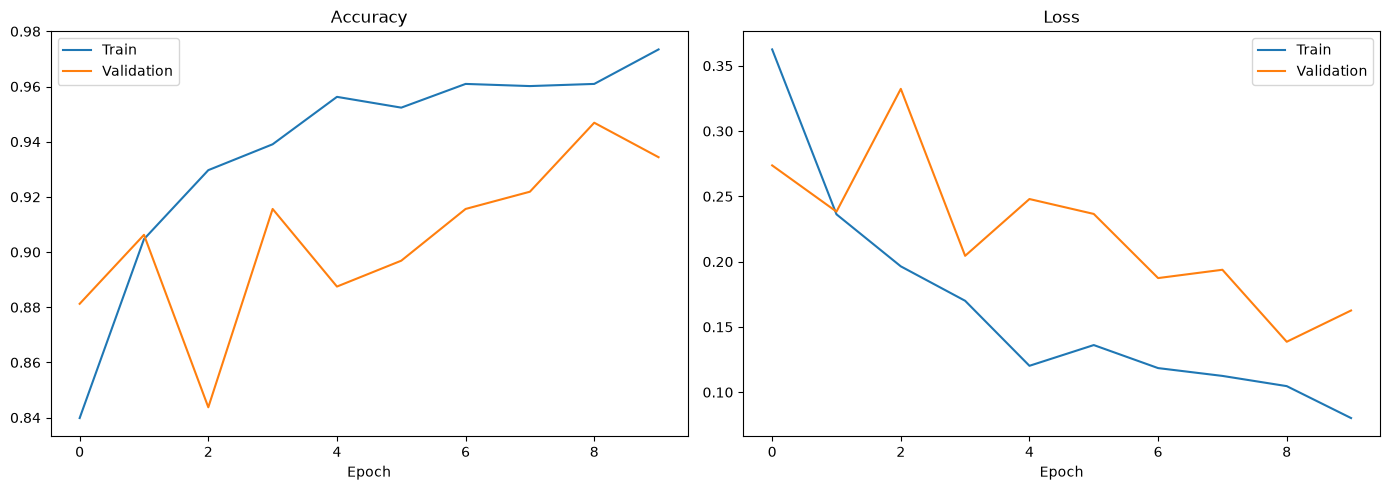

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(transfer_history.history['accuracy'], label='Train')
axes[0].plot(transfer_history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(transfer_history.history['loss'], label='Train')
axes[1].plot(transfer_history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

transfer_model.save("../models/mobilenetv2_fake_currency.keras")
print("Model saved successfully!")

Model saved successfully!
